In [9]:
import sys
import os
import glob
import calendar
import json
import warnings
warnings.filterwarnings('ignore')

from shapely import LineString
import pandas as pd
import numpy as np
import random
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates

import matplotlib.ticker as ticker
from matplotlib.ticker import EngFormatter

import time
import datetime as datetime
figsize = (20,10)

pd.options.mode.chained_assignment = None 

area_code_region = {1:"NNSW", 2:"CNSW", 3:"SNW", 4:"SNSW", 5:"WNV",
                        6:"MEL", 7:"SEV",  8:"NQ", 9:"CQ", 10:"GG",
                        11:"SQ", 12:"NSA", 13:"CSA", 14:"SESA", 15:"TAS"}  
    


In [7]:
def set_axes_tick_labels(ax1, loc):
    if loc == 1:
        ax1.xaxis.set_minor_locator(mdates.HourLocator(interval=2))
        ax1.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
        ax1.xaxis.grid(True,'minor',color='grey', alpha=0.9, ls='-', lw=0.4)

    
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
#ax1.xaxis.set_major_locator(mdates.HourLocator(interval=5))
#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    ax1.xaxis.grid(True,'major',color='grey', alpha=0.9, ls='-', lw=1.8)
    #ax1.yaxis.set_major_locator(MultipleLocator(200))
    #ax1.yaxis.grid(True,'major',color='grey', alpha=0.9, ls='-', lw=1.8)
# Optional: Add minor ticks
    #ax1.yaxis.set_minor_locator(MultipleLocator(50))
    #ax1.yaxis.grid(True,'minor',color='grey', alpha=0.9, ls='-', lw=0.4)
    ax1.set_ylabel("MW")
    for label in ax1.get_xticklabels():
        label.set_rotation(45) 
    return ax1

In [4]:
seq_res.columns

Index(['gas', 'Coal', 'hydro', 'PV', 'Battery', 'Wind', 'unserved_energy',
       'over_gen', 'Storage Charging', 'Storage Discharging', 'Stored Energy',
       'load'],
      dtype='object')

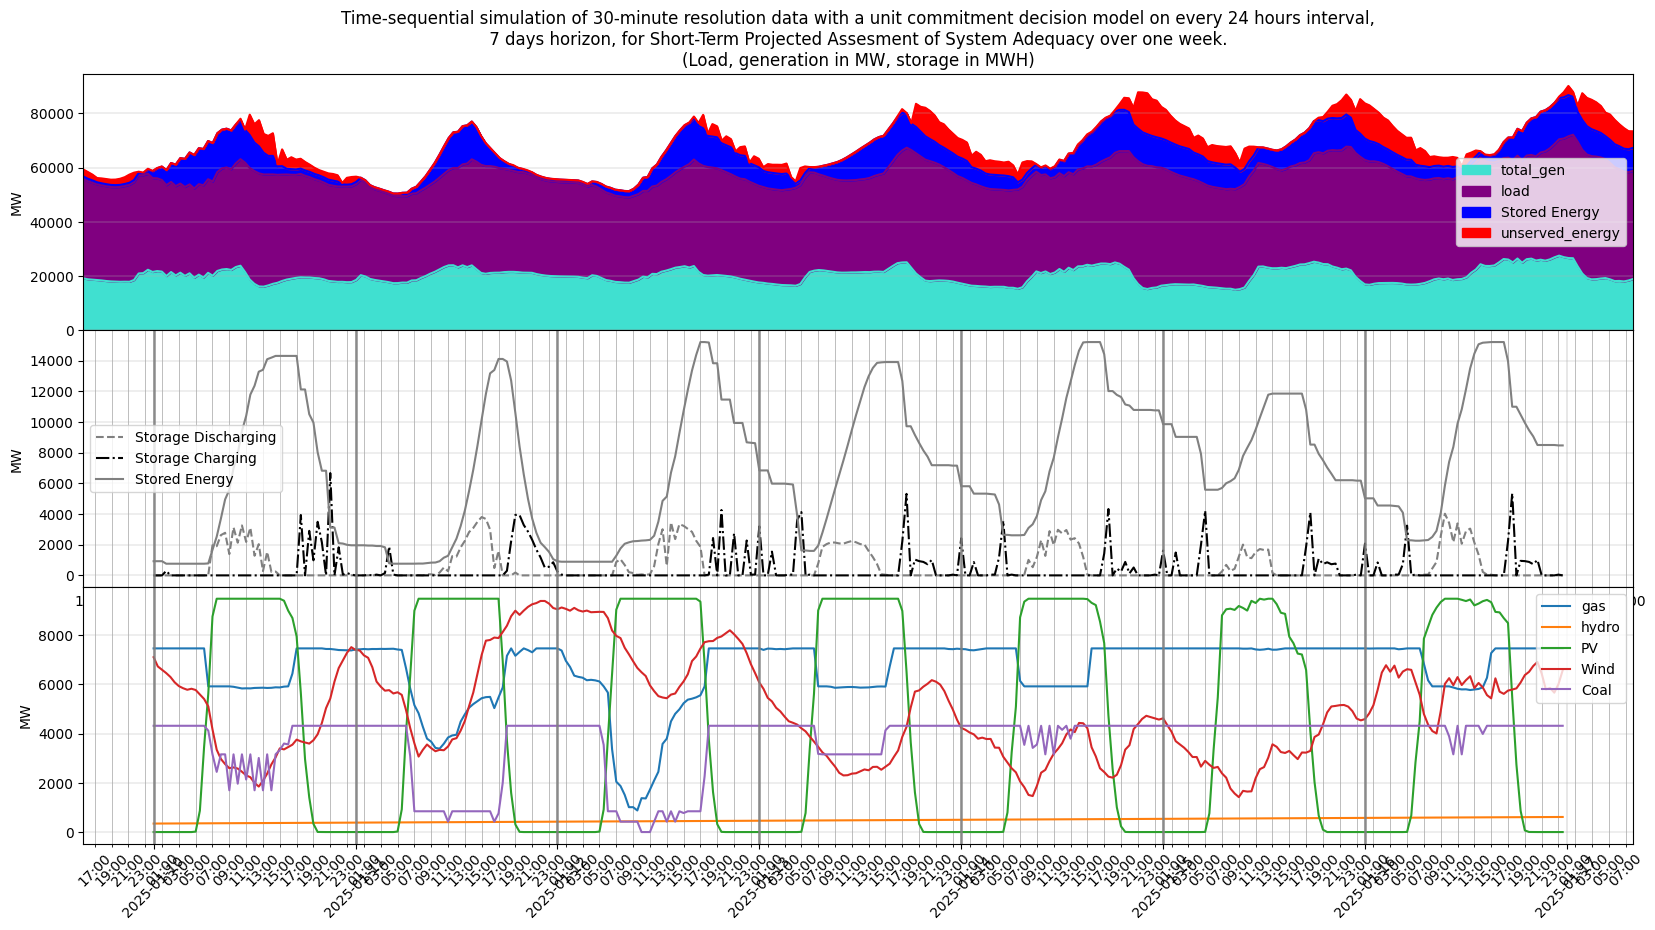

In [11]:
seq_res = pd.read_csv("../data/output/seq_sim_output_test_case.csv")
seq_res["timestamp"] = pd.to_datetime(seq_res["timestamp"])
seq_res = seq_res.set_index("timestamp")
seq_res["renewable"] = seq_res['PV'] + seq_res['Wind'] + seq_res['hydro'] 
seq_res["non-renewable"] = seq_res['Coal'] + seq_res['gas']  
seq_res["total_gen"] = seq_res["renewable"] + seq_res["non-renewable"]
fig, (ax1,ax2, ax3) = plt.subplots(figsize=figsize, nrows=3, ncols=1)
min_locator = 1
ax1 = set_axes_tick_labels(ax1, min_locator)
ax2 = set_axes_tick_labels(ax2, min_locator)
ax3 = set_axes_tick_labels(ax3, min_locator)

markers = ['s:', 'x--', 'o-', 'v-', '^-', '<-','--','-.','','','','','','','']
plt.subplots_adjust(wspace=0, hspace=0)
seq_res[["total_gen", "load", "Stored Energy", "unserved_energy"
        ]].plot.area(ax=ax1, color=['turquoise','purple',  'blue', 'red'])
#seq_res[['Storage Charging', 'Storage Discharging', "Stored Energy"]].plot(ax=ax2)


ax2.plot(seq_res.index, seq_res['Storage Charging'],  linestyle='--', 
         color='grey', label='Storage Discharging')
ax2.plot(seq_res.index, seq_res['Storage Discharging'],  linestyle='-.', 
         color='black', label='Storage Charging')
ax2.plot(seq_res.index, seq_res['Stored Energy'],  linestyle='-', 
         color='grey', label='Stored Energy')
ax2.legend()
#

#seq_res[['gas', 'hydro', 'biomass', 'PV', 'Wind', 'Distillate',
#       'Coal']].plot(ax=ax3, style=markers)
sel_cols = ['gas', 'hydro',  'PV', 'Wind', 
       'Coal']
for i, kk in enumerate(sel_cols):
    ax3.plot(seq_res.index, seq_res[kk], label=kk)
    
ax3.legend()


#ax1.tick_params(axis='x', which='both', rotation=45)

ax1.grid(linewidth=0.3)
ax2.grid(linewidth=0.3)
ax3.grid(linewidth=0.3)

ax3.tick_params(axis='x', which='both', rotation=45)
ax3.xaxis.set_minor_locator(mdates.HourLocator(interval=2))
ax3.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax3.xaxis.grid(True,'minor',color='grey', alpha=0.9, ls='-', lw=0.4)
ax3.yaxis.grid(True,'minor',color='grey', alpha=0.9, ls='-', lw=0.4)

ax1.tick_params(axis='x', which='both', rotation=45)
ax1.xaxis.set_minor_locator(mdates.HourLocator(interval=2))
ax1.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax1.xaxis.grid(True,'minor',color='grey', alpha=0.9, ls='-', lw=0.4)
ax1.yaxis.grid(True,'minor',color='grey', alpha=0.9, ls='-', lw=0.4)
for label in ax2.get_xticklabels():
        label.set_label("")

#ax1.xaxis.grid(True,'major',color='grey', alpha=0.9, ls='-', lw=1.8)
#ax2.xaxis.grid(True,'major',color='grey', alpha=0.9, ls='-', lw=1.8)
#ax3.xaxis.grid(True,'major',color='grey', alpha=0.9, ls='-', lw=1.8)

for kk in list(set(seq_res.index.date)):
    ax3.axvline(x=kk, color='grey', linestyle='-', alpha=0.9, linewidth=1.8)
    ax2.axvline(x=kk, color='grey', linestyle='-', alpha=0.9, linewidth=1.8)
#    ax1.axvline(x=kk, color='black', linestyle='-', linewidth=2.0)

title1 = "Time-sequential simulation of 30-minute resolution data with a unit commitment decision model on every 24 hours interval"
title2 = ",\n 7 days horizon, for Short-Term Projected Assesment of System Adequacy over one week. \n(Load, generation in MW, storage in MWH)"
title = title1 + title2
aa = ax1.set_title(title)
